# FM-01 — Sparse FM-base

목표는 08 LR의 수동 조합을 확장하는 것이 아니라, G·functional token·A_pair·exact·B/V/T/R/S에서 희소 변이 상호작용을 2차 multiclass FM이 직접 학습하는지 확인하는 것이다. contrast, 수동 gene-pair, binning, A_ref/A_alt, TF-IDF, SVD, 결측 노이즈는 제외한다.

모든 token 선택·recurrent 선택·numeric scale은 outer-train만 사용한다. count는 `log1p → fold-train std로만 나누기`로 처리하여 0값을 sparse inactive 상태로 유지한다. outer validation은 early stopping에 사용하지 않는다.

In [1]:
from pathlib import Path
import subprocess, sys
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def find_exp_model():
    for path in (Path.cwd(), *Path.cwd().parents):
        direct = path / 'common' / 'sparse_fm_runner.py'
        project = path / 'experiments' / 'gs' / 'notebooks' / 'exp_model' / 'common' / 'sparse_fm_runner.py'
        if direct.exists(): return path
        if project.exists(): return project.parent.parent
    raise FileNotFoundError('exp_model runner를 찾지 못했습니다.')

EXP_MODEL = find_exp_model()
RUNNER = EXP_MODEL / 'common' / 'sparse_fm_runner.py'
RESULT_DIR = EXP_MODEL / 'result'
RESULT_DIR.mkdir(exist_ok=True)
RUN_ID = 'FM-01'
SEEDS = (42, 2024, 777)
PREFLIGHT_ONLY = False  # 먼저 True로 seed42 첫 fold 실행성만 확인 후 False로 변경
RUN_EXPERIMENT = True
print({'runner': RUNNER, 'seeds': SEEDS, 'preflight_only': PREFLIGHT_ONLY})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model/common/sparse_fm_runner.py'), 'seeds': (42, 2024, 777), 'preflight_only': False}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if RUN_EXPERIMENT:
    run_seeds = (42,) if PREFLIGHT_ONLY else SEEDS
    for seed in tqdm(run_seeds, desc='FM-01 sparse FM', unit='seed'):
        command = [sys.executable, str(RUNNER), '--experiment', 'FM-01', '--seed', str(seed), '--run-id', RUN_ID]
        if PREFLIGHT_ONLY:
            command.append('--preflight')
        process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
        assert process.stdout is not None
        tail = []
        for line in process.stdout:
            print(line, end='')
            tail = (tail + [line])[-80:]
        return_code = process.wait()
        if return_code:
            raise RuntimeError(f'seed={seed} runner failed (exit={return_code}). Last runner output:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 결과 집계만 수행합니다.')

FM-01 sparse FM:   0%|          | 0/3 [00:00<?, ?seed/s]


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 394.46it/s]

FM 01 | seed 42:   0%|          | 0/5 [00:00<?, ?it/s]
FM 01 | seed 42:  20%|██        | 1/5 [04:32<18:10, 272.55s/it]
FM 01 | seed 42:  40%|████      | 2/5 [10:11<15:35, 311.79s/it]
FM 01 | seed 42:  60%|██████    | 3/5 [14:24<09:29, 284.84s/it]
FM 01 | seed 42:  80%|████████  | 4/5 [19:48<05:00, 300.35s/it]
FM 01 | seed 42: 100%|██████████| 5/5 [24:41<00:00, 297.67s/it]
FM 01 | seed 42: 100%|██████████| 5/5 [24:41<00:00, 296.32s/it]
{
  "experiment_id": "FM-01",
  "seed": 42,
  "fm_oof_macro_f1": 0.28129876319932456,
  "lr08_oof_macro_f1": 0.4825927951809337,
  "blend_0p5_oof_macro_f1": 0.4406429735692343,
  "delta_fm_vs_lr08": -0.2012940319816091,
  "delta_blend_vs_lr08": -0.041949821611699356,
  "feature_count_mean": 14496.0,
  "early_stopping_epoch_mean": 1.0,
  "runtime_seconds": 1481.7561329579912,
  "device": "mps",
  "loss_finite": true,
  "leakage_check": true,
  "nan_as_mutation_count": 0,
  "pa

FM-01 sparse FM:  33%|███▎      | 1/3 [25:04<50:09, 1504.53s/seed]


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 404.40it/s]

FM 01 | seed 2024:   0%|          | 0/5 [00:00<?, ?it/s]
FM 01 | seed 2024:  20%|██        | 1/5 [04:17<17:09, 257.43s/it]
FM 01 | seed 2024:  40%|████      | 2/5 [08:39<13:00, 260.30s/it]
FM 01 | seed 2024:  60%|██████    | 3/5 [13:01<08:41, 260.90s/it]
FM 01 | seed 2024:  80%|████████  | 4/5 [18:08<04:39, 279.06s/it]
FM 01 | seed 2024: 100%|██████████| 5/5 [23:30<00:00, 294.72s/it]
FM 01 | seed 2024: 100%|██████████| 5/5 [23:30<00:00, 282.15s/it]
{
  "experiment_id": "FM-01",
  "seed": 2024,
  "fm_oof_macro_f1": 0.2758734463131493,
  "lr08_oof_macro_f1": 0.47966653196064707,
  "blend_0p5_oof_macro_f1": 0.4281838658187093,
  "delta_fm_vs_lr08": -0.20379308564749776,
  "delta_blend_vs_lr08": -0.05148266614193775,
  "feature_count_mean": 14495.2,
  "early_stopping_epoch_mean": 1.0,
  "runtime_seconds": 1410.9101911659818,
  "device": "mps",
  "loss_finite": true,
  "leakage_check": true,
  "nan_as_mutation_

FM-01 sparse FM:  67%|██████▋   | 2/3 [48:58<24:22, 1463.00s/seed]


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 394.48it/s]

FM 01 | seed 777:   0%|          | 0/5 [00:00<?, ?it/s]
FM 01 | seed 777:  20%|██        | 1/5 [04:23<17:32, 263.08s/it]
FM 01 | seed 777:  40%|████      | 2/5 [08:32<12:44, 254.95s/it]
FM 01 | seed 777:  60%|██████    | 3/5 [15:00<10:31, 315.89s/it]
FM 01 | seed 777:  80%|████████  | 4/5 [19:40<05:01, 301.61s/it]
FM 01 | seed 777: 100%|██████████| 5/5 [25:30<00:00, 318.96s/it]
FM 01 | seed 777: 100%|██████████| 5/5 [25:30<00:00, 306.04s/it]
{
  "experiment_id": "FM-01",
  "seed": 777,
  "fm_oof_macro_f1": 0.28876287105149445,
  "lr08_oof_macro_f1": 0.4837840884370487,
  "blend_0p5_oof_macro_f1": 0.4306836024618992,
  "delta_fm_vs_lr08": -0.19502121738555422,
  "delta_blend_vs_lr08": -0.05310048597514949,
  "feature_count_mean": 14493.8,
  "early_stopping_epoch_mean": 1.4,
  "runtime_seconds": 1530.328473874979,
  "device": "mps",
  "loss_finite": true,
  "leakage_check": true,
  "nan_as_mutation_count": 0

FM-01 sparse FM: 100%|██████████| 3/3 [1:14:52<00:00, 1497.53s/seed]


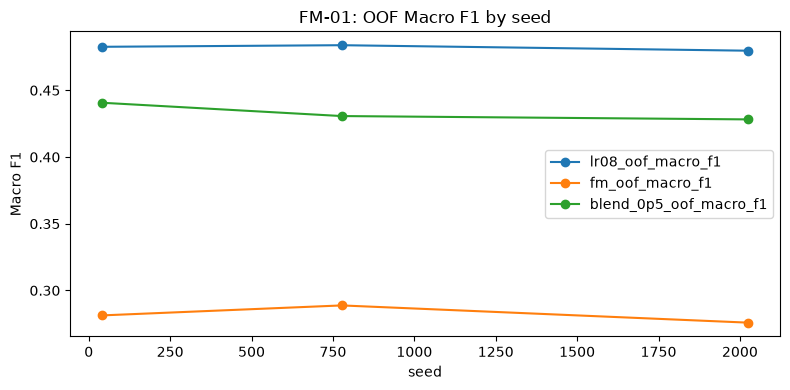

,experiment_id,seed,fm_oof_macro_f1,lr08_oof_macro_f1,blend_0p5_oof_macro_f1,delta_fm_vs_lr08,delta_blend_vs_lr08,feature_count_mean,early_stopping_epoch_mean,runtime_seconds,device,loss_finite,leakage_check,nan_as_mutation_count,parameters
0,FM-01,42,0.281299,0.482593,0.440643,-0.201294,-0.041950,14496.0,1.0,1481.756133,mps,True,True,0,"{""rank"": 16, ""lr"": 0.001, ""weight_decay"": 1e-0..."
2,FM-01,777,0.288763,0.483784,0.430684,-0.195021,-0.053100,14493.8,1.4,1530.328474,mps,True,True,0,"{""rank"": 16, ""lr"": 0.001, ""weight_decay"": 1e-0..."
1,FM-01,2024,0.275873,0.479667,0.428184,-0.203793,-0.051483,14495.2,1.0,1410.910191,mps,True,True,0,"{""rank"": 16, ""lr"": 0.001, ""weight_decay"": 1e-0..."


,experiment_id,seed_count,fm_macro_f1_mean,fm_macro_f1_std,lr08_macro_f1_mean,blend_macro_f1_mean,blend_macro_f1_std,blend_delta_vs_lr08_mean,all_seed_blend_delta_positive,feature_count_mean,runtime_seconds_mean,loss_finite,leakage_check,nan_as_mutation_count
0,FM-01,3,0.281978,0.006472,0.482014,0.43317,0.006591,-0.048844,False,14495.0,1474.331599,True,True,0


In [3]:
if PREFLIGHT_ONLY:
    path = RESULT_DIR / 'FM-01_FM-01_seed42_preflight.csv'
    display(pd.read_csv(path))
else:
    files = [RESULT_DIR / f'FM-01_FM-01_seed{seed}_oof.csv' for seed in SEEDS]
    missing = [str(path) for path in files if not path.exists()]
    if missing: raise FileNotFoundError('누락 결과:\n' + '\n'.join(missing))
    per_seed = pd.concat([pd.read_csv(path) for path in files], ignore_index=True).sort_values('seed')
    assert per_seed.leakage_check.all() and per_seed.nan_as_mutation_count.eq(0).all() and per_seed.loss_finite.all()
    summary = pd.DataFrame([{
        'experiment_id': RUN_ID, 'seed_count': len(SEEDS),
        'fm_macro_f1_mean': per_seed.fm_oof_macro_f1.mean(), 'fm_macro_f1_std': per_seed.fm_oof_macro_f1.std(),
        'lr08_macro_f1_mean': per_seed.lr08_oof_macro_f1.mean(),
        'blend_macro_f1_mean': per_seed.blend_0p5_oof_macro_f1.mean(), 'blend_macro_f1_std': per_seed.blend_0p5_oof_macro_f1.std(),
        'blend_delta_vs_lr08_mean': per_seed.delta_blend_vs_lr08.mean(), 'all_seed_blend_delta_positive': bool(per_seed.delta_blend_vs_lr08.gt(0).all()),
        'feature_count_mean': per_seed.feature_count_mean.mean(), 'runtime_seconds_mean': per_seed.runtime_seconds.mean(),
        'loss_finite': bool(per_seed.loss_finite.all()), 'leakage_check': bool(per_seed.leakage_check.all()), 'nan_as_mutation_count': int(per_seed.nan_as_mutation_count.sum()),
    }])
    per_seed.to_csv(RESULT_DIR / 'FM-01_3seed_per_seed.csv', index=False)
    summary.to_csv(RESULT_DIR / 'FM-01_3seed_summary.csv', index=False)
    ax = per_seed.plot(x='seed', y=['lr08_oof_macro_f1', 'fm_oof_macro_f1', 'blend_0p5_oof_macro_f1'], marker='o', figsize=(8, 4), title='FM-01: OOF Macro F1 by seed')
    ax.set_ylabel('Macro F1'); plt.tight_layout(); plt.savefig(RESULT_DIR / 'FM-01_oof_macro_f1.png', dpi=160); plt.show()
    display(per_seed); display(summary)